<a href="https://colab.research.google.com/github/Lathika-M732/-24ADI003_24BAD062_EX-4/blob/main/Copy_of_Ex_4_DL_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# TASK A: DATASET PREPARATION

TASK A: DATASET PREPARATION
Name    : Lathika M.
Roll No : 24BAD062
Using Colab cache for faster access to the 'intel-image-classification' dataset.

Dataset downloaded successfully.
Dataset location:
/kaggle/input/intel-image-classification

Dataset Path:
/kaggle/input/intel-image-classification/seg_train/seg_train
Found 14034 files belonging to 6 classes.

Classes:
0 : buildings
1 : forest
2 : glacier
3 : mountain
4 : sea
5 : street

Number of Classes: 6

Dataset Split
----------------------------------------
Training batches   : 307
Validation batches : 65
Testing batches    : 67


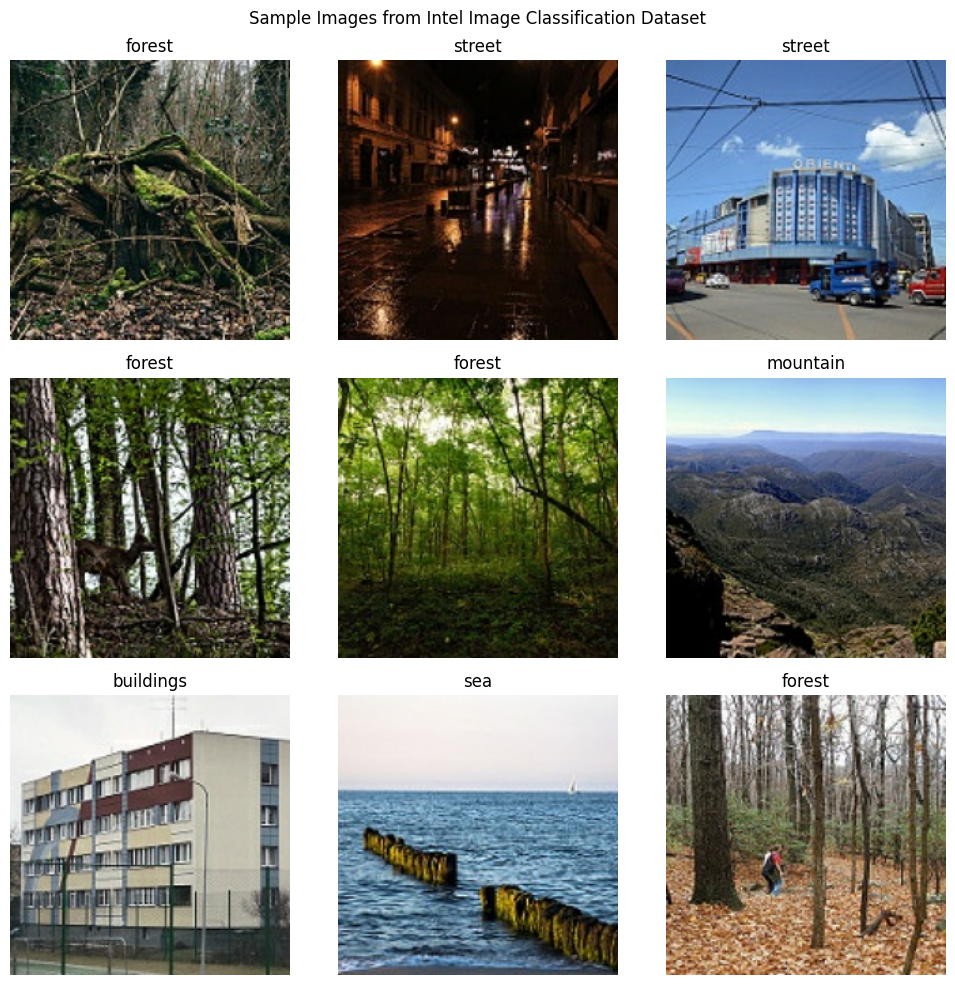


Task A completed successfully.


In [ ]:
# ============================================================
# TASK A: DATASET PREPARATION
# ============================================================

# Name     : Lathika M.
# Roll No  : 24BAD062

print("=" * 60)
print("TASK A: DATASET PREPARATION")
print("Name    : Lathika M.")
print("Roll No : 24BAD062")
print("=" * 60)


# STEP 1: INSTALL KAGGLEHUB

!pip install -q kagglehub


# STEP 2: IMPORT LIBRARIES

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub


# STEP 3: DOWNLOAD DATASET FROM KAGGLE

path = kagglehub.dataset_download(
    "puneet6060/intel-image-classification"
)

print("\nDataset downloaded successfully.")
print("Dataset location:")
print(path)


# STEP 4: FIND TRAINING DATASET

dataset_path = os.path.join(
    path,
    "seg_train",
    "seg_train"
)

print("\nDataset Path:")
print(dataset_path)


# STEP 5: IMAGE PARAMETERS

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42


# STEP 6: LOAD DATASET

full_dataset = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED
)


# STEP 7: DISPLAY CLASS NAMES

class_names = full_dataset.class_names

print("\nClasses:")

for i, name in enumerate(class_names):

    print(i, ":", name)


print("\nNumber of Classes:",
      len(class_names))


# STEP 8: SPLIT DATASET

dataset_size = tf.data.experimental.cardinality(
    full_dataset
).numpy()

train_size = int(
    0.70 * dataset_size
)

validation_size = int(
    0.15 * dataset_size
)

test_size = (
    dataset_size
    - train_size
    - validation_size
)


train_dataset = full_dataset.take(
    train_size
)


remaining_dataset = full_dataset.skip(
    train_size
)


validation_dataset = remaining_dataset.take(
    validation_size
)


test_dataset = remaining_dataset.skip(
    validation_size
)


print("\nDataset Split")
print("-" * 40)

print(
    "Training batches   :",
    train_size
)

print(
    "Validation batches :",
    validation_size
)

print(
    "Testing batches    :",
    test_size
)


# STEP 9: PREFETCH DATA

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    AUTOTUNE
)


# STEP 10: DISPLAY SAMPLE IMAGES

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")


plt.suptitle(
    "Sample Images from Intel Image Classification Dataset"
)

plt.tight_layout()

plt.show()


print("\nTask A completed successfully.")

# TASK B: IMPLEMENTING TRANSFER LEARNING

In [ ]:
# ============================================================
# TASK B: IMPLEMENTING TRANSFER LEARNING
# ============================================================

# Name     : Lathika M.
# Roll No  : 24BAD062

print("=" * 60)
print("TASK B: IMPLEMENTING TRANSFER LEARNING")
print("Name    : Lathika M.")
print("Roll No : 24BAD062")
print("=" * 60)


# STEP 1: IMPORT LIBRARIES

import tensorflow as tf

from tensorflow.keras import layers

from tensorflow.keras import models

from tensorflow.keras.applications import ResNet50

from tensorflow.keras.applications.resnet50 import preprocess_input


# STEP 2: NUMBER OF CLASSES

NUM_CLASSES = len(class_names)

print(
    "Number of Classes:",
    NUM_CLASSES
)


# STEP 3: LOAD PRE-TRAINED RESNET-50

base_model = ResNet50(

    weights="imagenet",

    include_top=False,

    input_shape=(224, 224, 3)
)


print("\nResNet-50 loaded successfully.")


# STEP 4: FREEZE FEATURE EXTRACTION LAYERS

base_model.trainable = False

print(
    "Feature extraction layers are frozen."
)


# STEP 5: CREATE TRANSFER LEARNING MODEL

model = models.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    layers.Lambda(
        preprocess_input
    ),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])


# STEP 6: DISPLAY MODEL SUMMARY

print("\nModel Summary:")

model.summary()


# STEP 7: COMPILE MODEL

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


print("\nModel compiled successfully.")

print("\nTask B completed successfully.")

TASK B: IMPLEMENTING TRANSFER LEARNING
Name    : Lathika M.
Roll No : 24BAD062
Number of Classes: 6
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

ResNet-50 loaded successfully.
Feature extraction layers are frozen.

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)


Model compiled successfully.

Task B completed successfully.


# TASK C: MODEL TRAINING AND PERFORMANCE EVALUATION

In [ ]:
# ============================================================
# TASK C: MODEL TRAINING AND PERFORMANCE EVALUATION
# ============================================================

# Name     : Lathika M.
# Roll No  : 24BAD062

print("=" * 60)
print("TASK C: MODEL TRAINING AND PERFORMANCE EVALUATION")
print("Name    : Lathika M.")
print("Roll No : 24BAD062")
print("=" * 60)


# ============================================================
# STEP 1: INSTALL KAGGLEHUB
# ============================================================

!pip install -q kagglehub


# ============================================================
# STEP 2: IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from tensorflow.keras import layers
from tensorflow.keras import models

from tensorflow.keras.applications import ResNet50

from tensorflow.keras.applications.resnet50 import preprocess_input


# ============================================================
# STEP 3: DOWNLOAD DATASET FROM KAGGLE
# ============================================================

print("\nDownloading Kaggle dataset...")

path = kagglehub.dataset_download(
    "puneet6060/intel-image-classification"
)

print("Dataset downloaded successfully.")

print("Dataset location:")
print(path)


# ============================================================
# STEP 4: SET DATASET PATH
# ============================================================

dataset_path = os.path.join(
    path,
    "seg_train",
    "seg_train"
)

print("\nDataset Path:")
print(dataset_path)


# ============================================================
# STEP 5: IMAGE PARAMETERS
# ============================================================

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42


# ============================================================
# STEP 6: LOAD DATASET
# ============================================================

print("\nLoading images...")

full_dataset = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED
)


# ============================================================
# STEP 7: GET CLASS NAMES
# ============================================================

class_names = full_dataset.class_names

NUM_CLASSES = len(class_names)

print("\nClasses:")

for i, name in enumerate(class_names):

    print(i, ":", name)

print("\nNumber of Classes:", NUM_CLASSES)


# ============================================================
# STEP 8: SPLIT DATASET
# ============================================================

dataset_size = tf.data.experimental.cardinality(
    full_dataset
).numpy()

train_size = int(
    0.70 * dataset_size
)

validation_size = int(
    0.15 * dataset_size
)

test_size = (
    dataset_size
    - train_size
    - validation_size
)


train_dataset = full_dataset.take(
    train_size
)


remaining_dataset = full_dataset.skip(
    train_size
)


validation_dataset = remaining_dataset.take(
    validation_size
)


test_dataset = remaining_dataset.skip(
    validation_size
)


print("\nDataset Split")
print("-" * 40)

print(
    "Training batches   :",
    train_size
)

print(
    "Validation batches :",
    validation_size
)

print(
    "Testing batches    :",
    test_size
)


# ============================================================
# STEP 9: PREFETCH DATA
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    AUTOTUNE
)


# ============================================================
# STEP 10: LOAD PRE-TRAINED RESNET-50
# ============================================================

print("\nLoading ResNet-50...")

base_model = ResNet50(

    weights="imagenet",

    include_top=False,

    input_shape=(224, 224, 3)
)

print("ResNet-50 loaded successfully.")


# ============================================================
# STEP 11: FREEZE FEATURE EXTRACTION LAYERS
# ============================================================

base_model.trainable = False

print(
    "ResNet-50 feature extraction layers are frozen."
)


# ============================================================
# STEP 12: CREATE TRANSFER LEARNING MODEL
# ============================================================

model = models.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    layers.Lambda(
        preprocess_input
    ),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])


# ============================================================
# STEP 13: COMPILE MODEL
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


print("\nModel compiled successfully.")


# ============================================================
# STEP 14: TRAIN MODEL
# ============================================================

EPOCHS = 5

print("\nStarting training...")

history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=EPOCHS
)


# ============================================================
# STEP 15: GET PERFORMANCE VALUES
# ============================================================

train_accuracy = history.history["accuracy"]

validation_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]

validation_loss = history.history["val_loss"]


# ============================================================
# STEP 16: DISPLAY PERFORMANCE
# ============================================================

print("\n")
print("=" * 60)
print("TRAINING PERFORMANCE")
print("=" * 60)


for i in range(EPOCHS):

    print(
        "Epoch", i + 1,
        "| Training Accuracy:",
        round(train_accuracy[i], 4),
        "| Validation Accuracy:",
        round(validation_accuracy[i], 4),
        "| Training Loss:",
        round(train_loss[i], 4),
        "| Validation Loss:",
        round(validation_loss[i], 4)
    )


# ============================================================
# STEP 17: TEST THE MODEL
# ============================================================

print("\nEvaluating on test dataset...")

test_loss, test_accuracy = model.evaluate(
    test_dataset
)


# ============================================================
# STEP 18: DISPLAY TEST ACCURACY
# ============================================================

print("\n")
print("=" * 60)
print("TEST PERFORMANCE")
print("=" * 60)

print(
    "Test Loss     :",
    round(test_loss, 4)
)

print(
    "Test Accuracy :",
    round(test_accuracy, 4)
)


# ============================================================
# STEP 19: ACCURACY VS EPOCH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    validation_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()

plt.grid()

plt.show()


# ============================================================
# STEP 20: LOSS VS EPOCH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    validation_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.legend()

plt.grid()

plt.show()


# ============================================================
# STEP 21: SAMPLE PREDICTIONS
# ============================================================

print("\nGenerating sample predictions...")


plt.figure(figsize=(12, 8))


for images, labels in test_dataset.take(1):

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    for i in range(min(9, len(images))):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        actual = class_names[
            labels[i]
        ]

        predicted = class_names[
            predicted_classes[i]
        ]

        plt.title(
            "Actual: " + actual +
            "\nPredicted: " + predicted
        )

        plt.axis("off")


plt.suptitle(
    "ResNet-50 Transfer Learning Predictions"
)

plt.tight_layout()

plt.show()


# ============================================================
# STEP 22: FINAL PERFORMANCE SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 60)

print("Name                : Lathika M.")
print("Roll No             : 24BAD062")

print(
    "Training Accuracy   :",
    round(train_accuracy[-1], 4)
)

print(
    "Validation Accuracy :",
    round(validation_accuracy[-1], 4)
)

print(
    "Training Loss       :",
    round(train_loss[-1], 4)
)

print(
    "Validation Loss     :",
    round(validation_loss[-1], 4)
)

print(
    "Test Accuracy       :",
    round(test_accuracy, 4)
)

print("=" * 60)

print("\nTask C completed successfully.")

TASK C: MODEL TRAINING AND PERFORMANCE EVALUATION
Name    : Lathika M.
Roll No : 24BAD062

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset downloaded successfully.
Dataset location:
/kaggle/input/intel-image-classification

Dataset Path:
/kaggle/input/intel-image-classification/seg_train/seg_train

Loading images...
Found 14034 files belonging to 6 classes.

Classes:
0 : buildings
1 : forest
2 : glacier
3 : mountain
4 : sea
5 : street

Number of Classes: 6

Dataset Split
----------------------------------------
Training batches   : 307
Validation batches : 65
Testing batches    : 67

Loading ResNet-50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet-50 loaded successfully.
ResNet-50 feature extraction layers are frozen.

Model compiled successfully.

Starting training...
Epoch 1/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 2134s 7s/step - accuracy: 0.5954 - loss: 1.0863 - val_accuracy: 0.8707 - val_loss: 0.4211
Epoch 2/5
307/307 ━━━━━━━━━━━━━━━━━━

# TASK D: USING HUGGING FACE PRE-TRAINED MODELS

In [ ]:
# ============================================================
# TASK D: USING HUGGING FACE PRE-TRAINED MODELS
# Name    : Lathika M.
# Roll No : 24BAD062
# ============================================================

!pip install -q transformers torch pillow

from transformers import pipeline
from PIL import Image
import numpy as np

# Load Hugging Face pre-trained model
hf_model = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

# Get one sample image
for images, labels in test_dataset.take(1):

    image = Image.fromarray(
        images[0].numpy().astype("uint8")
    )

    actual = class_names[labels[0]]

    # Hugging Face prediction
    hf_result = hf_model(image)[0]

    # ResNet-50 prediction
    prediction = model.predict(
        np.expand_dims(np.array(image), axis=0),
        verbose=0
    )

    predicted = class_names[
        np.argmax(prediction[0])
    ]

    print("=" * 50)
    print("TASK D: MODEL COMPARISON")
    print("=" * 50)

    print("Actual Class        :", actual)

    print(
        "ResNet-50 Prediction:",
        predicted
    )

    print(
        "Hugging Face Prediction:",
        hf_result["label"]
    )

    print(
        "Hugging Face Confidence:",
        round(hf_result["score"], 4)
    )

    break

# Observations

print("\nOBSERVATION:")
print("ResNet-50 and Hugging Face ViT were used for image classification.")
print("Their predictions may differ because they use different architectures.")
print("The Hugging Face model is a pre-trained Vision Transformer.")
